In [ ]:
import io
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.svm import SVR

!pip install mlxtend==0.22.0
from mlxtend.feature_selection import SequentialFeatureSelector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.7 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.3
    Uninstalling mlxtend-0.23.3:
      Successfully uninstalled mlxtend-0.23.3


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/all_seasons.csv')
data.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [ ]:
data['draft_year'] = pd.to_numeric(data['draft_year'], errors='coerce').fillna(0).astype(int)
data['draft_round'] = pd.to_numeric(data['draft_round'], errors='coerce').fillna(0).astype(int)
data['draft_number'] = pd.to_numeric(data['draft_number'], errors='coerce').fillna(0).astype(int)
data.drop(['Unnamed: 0'],axis=1,inplace=True)

# Only dropped rows with nonsensical 0 entries
cols_to_check = [col for col in data.columns
                 if col not in ['reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct']]

data = data[~(data[cols_to_check] == 0).any(axis=1)]
data.reset_index(drop=True, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        10178 non-null  object 
 1   team_abbreviation  10178 non-null  object 
 2   age                10178 non-null  float64
 3   player_height      10178 non-null  float64
 4   player_weight      10178 non-null  float64
 5   college            8597 non-null   object 
 6   country            10178 non-null  object 
 7   draft_year         10178 non-null  int64  
 8   draft_round        10178 non-null  int64  
 9   draft_number       10178 non-null  int64  
 10  gp                 10178 non-null  int64  
 11  pts                10178 non-null  float64
 12  reb                10178 non-null  float64
 13  ast                10178 non-null  float64
 14  net_rating         10178 non-null  float64
 15  oreb_pct           10178 non-null  float64
 16  dreb_pct           101

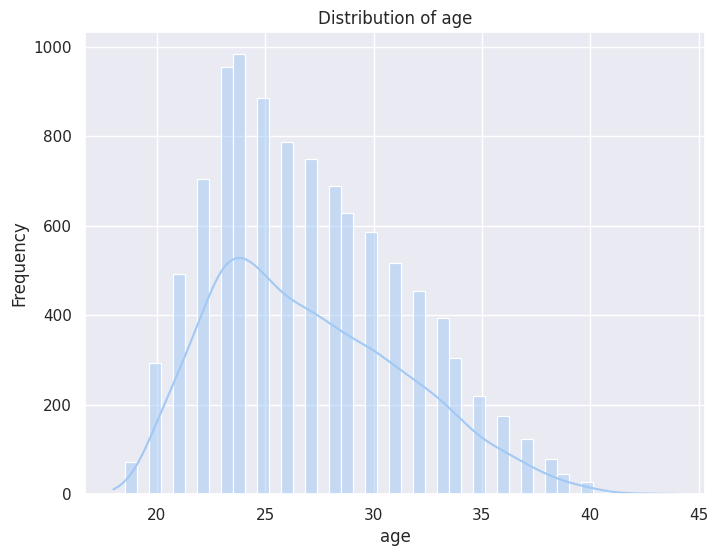

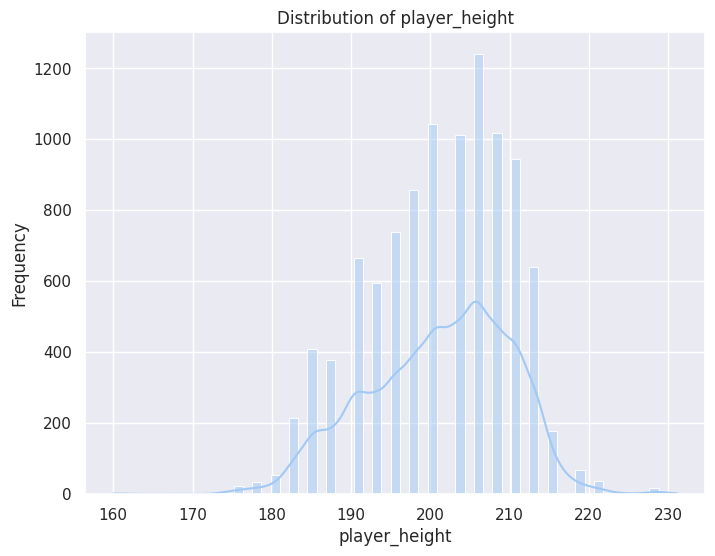

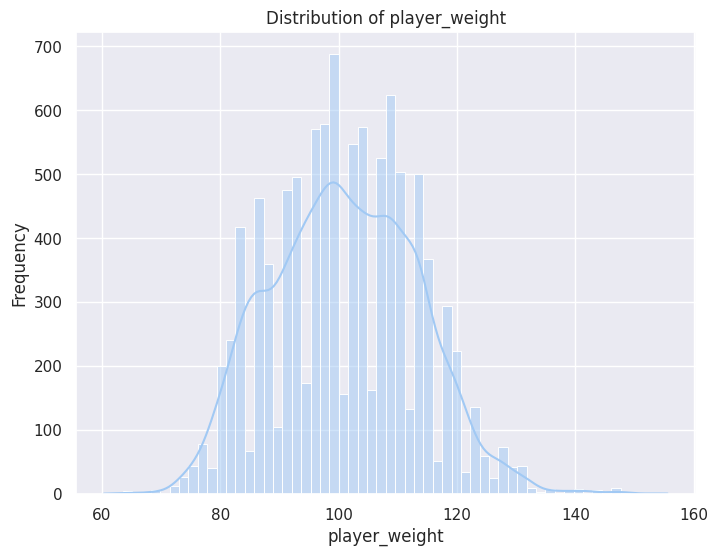

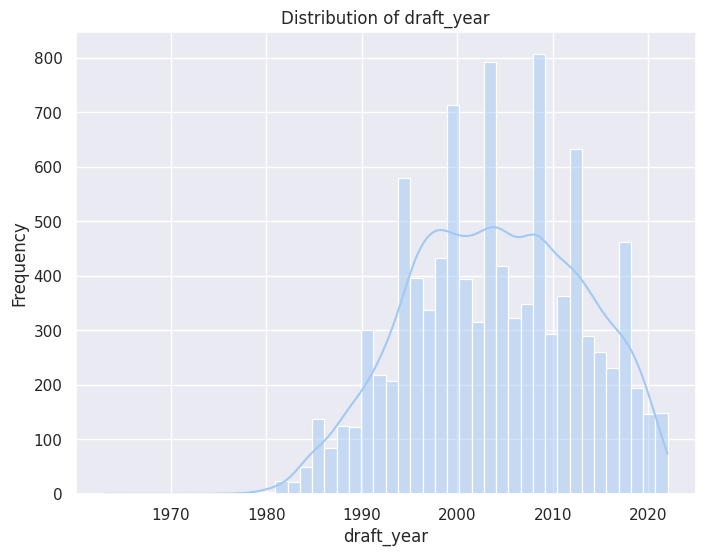

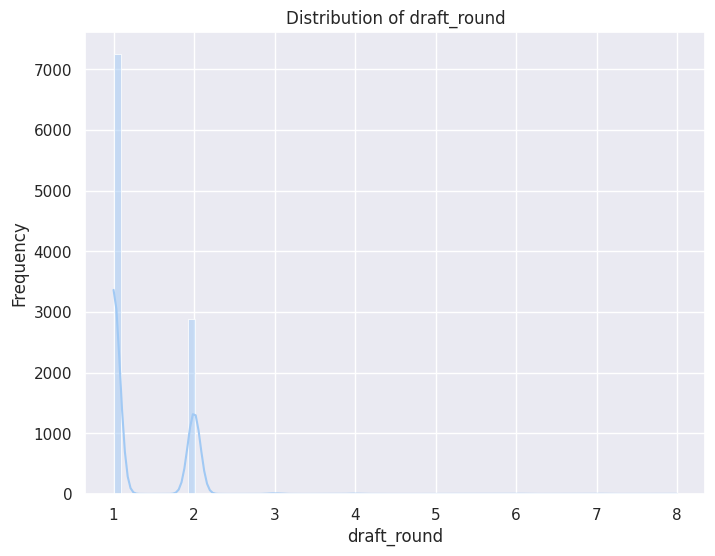

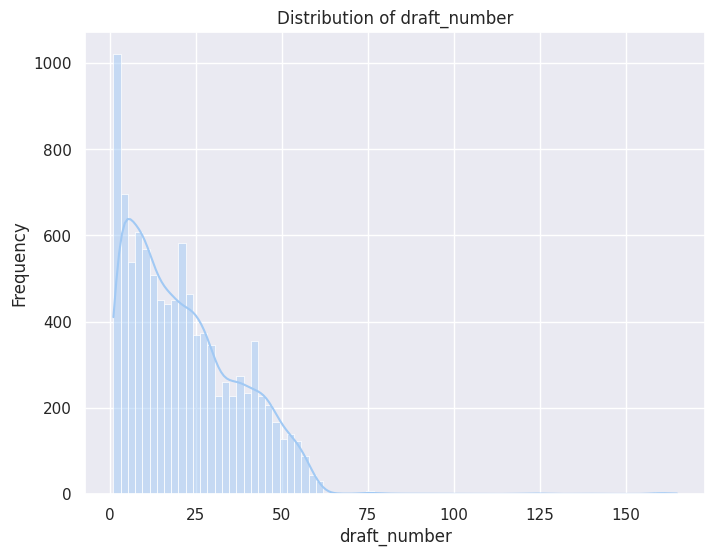

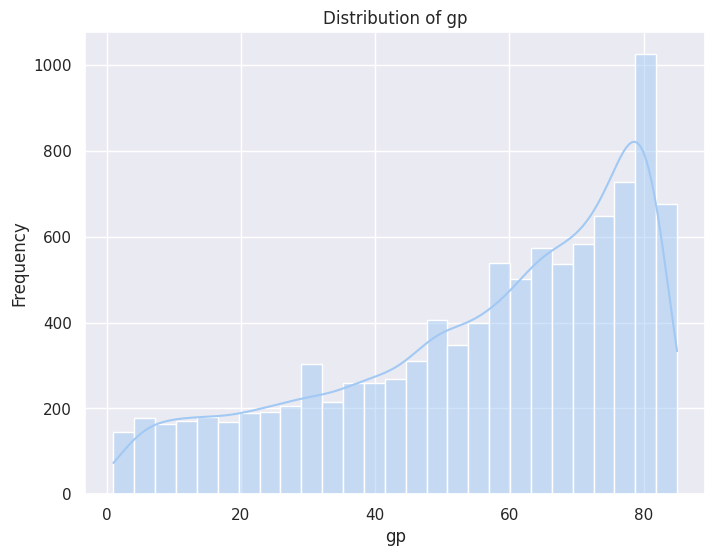

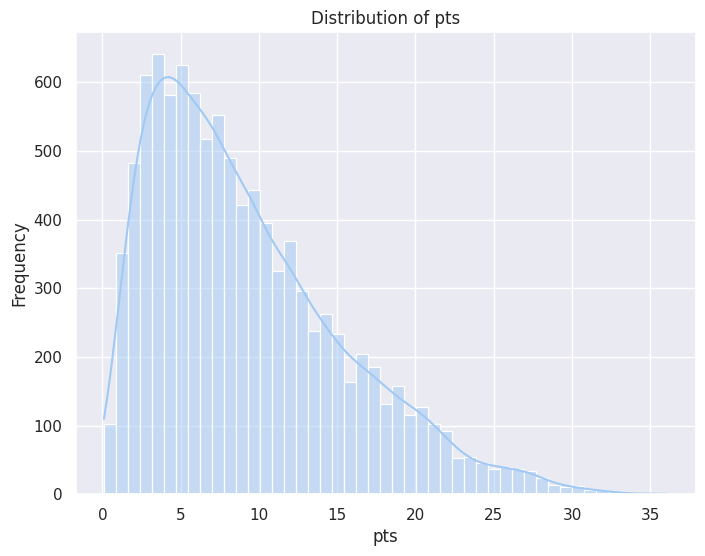

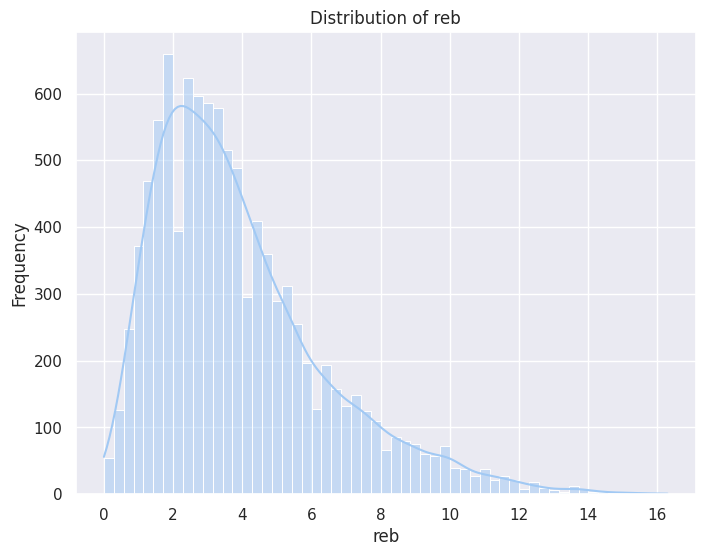

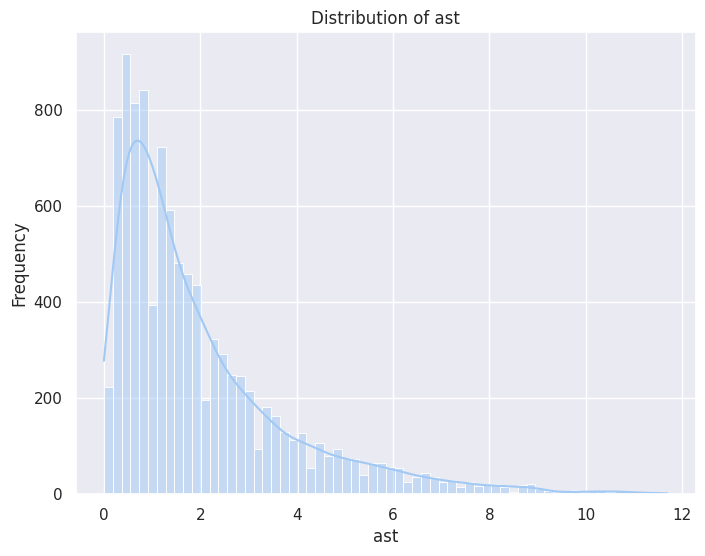

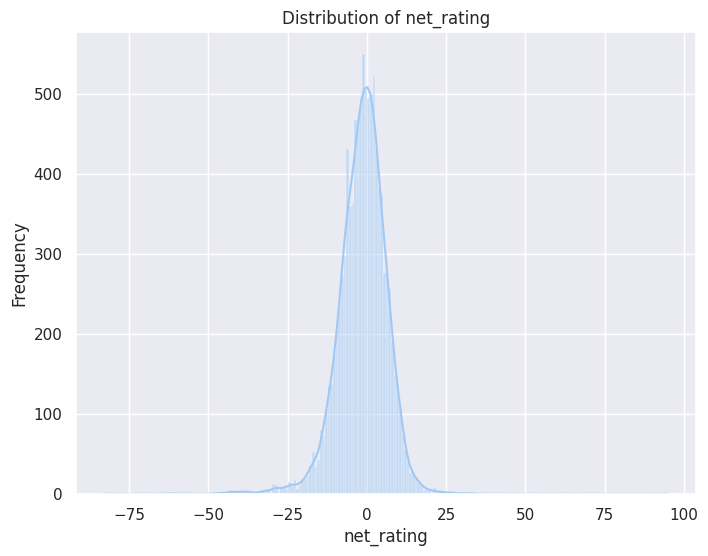

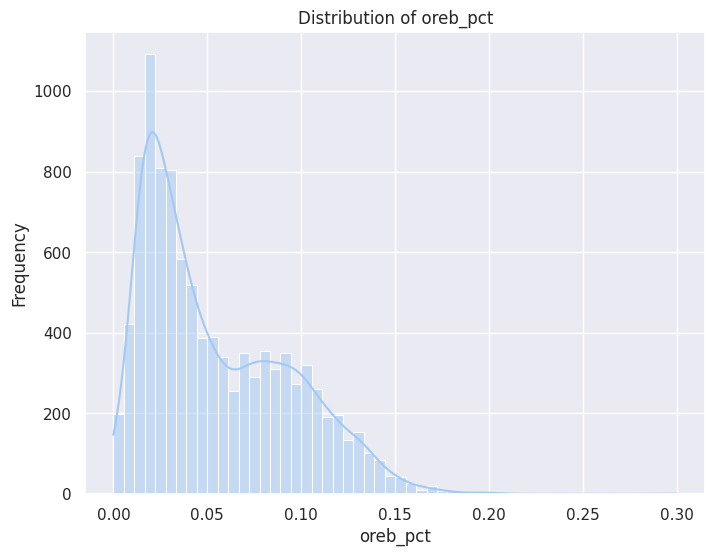

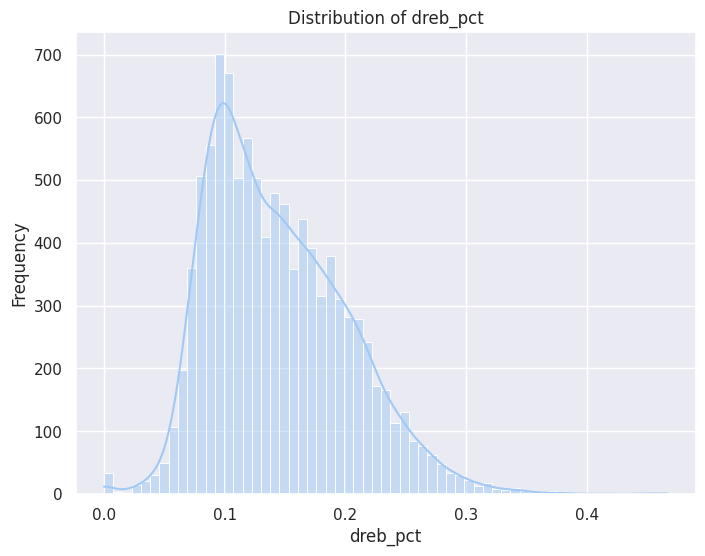

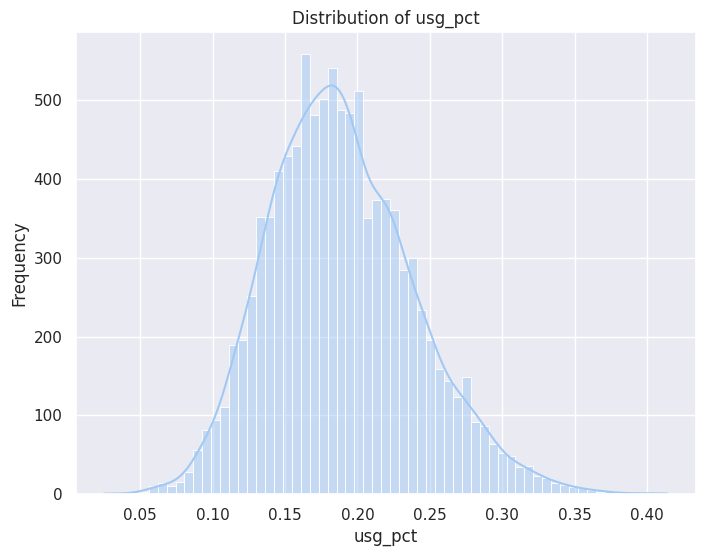

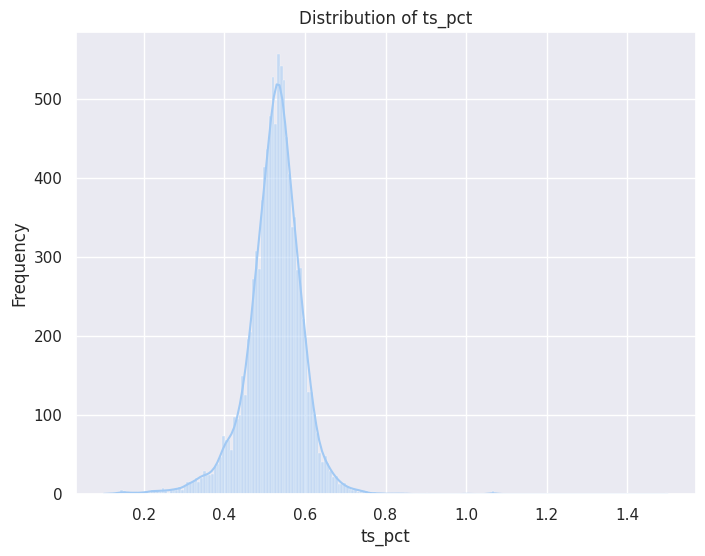

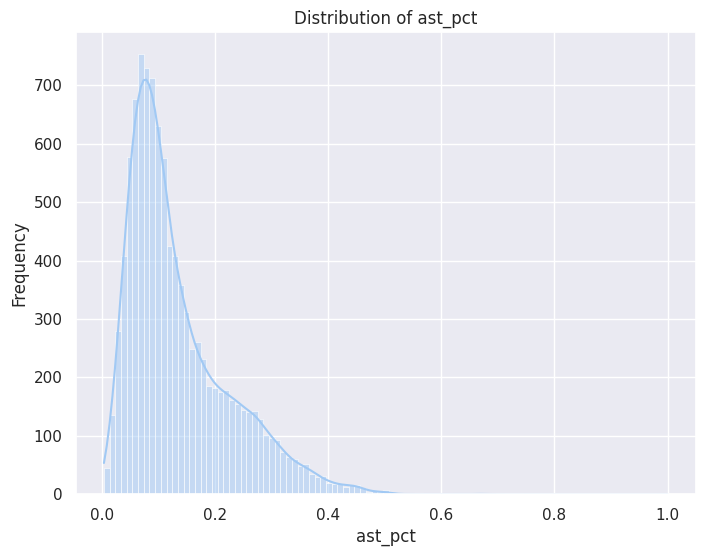

In [ ]:
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
sns.set(style="darkgrid")
sns.set_palette("pastel")
# Create histograms with distribution lines
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

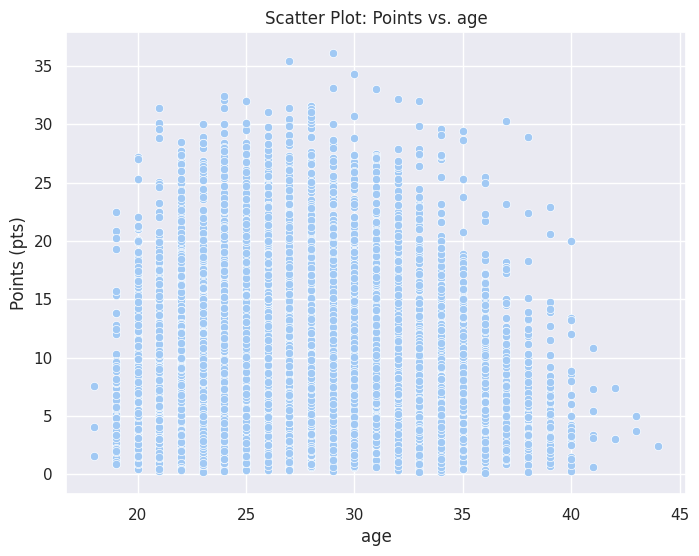

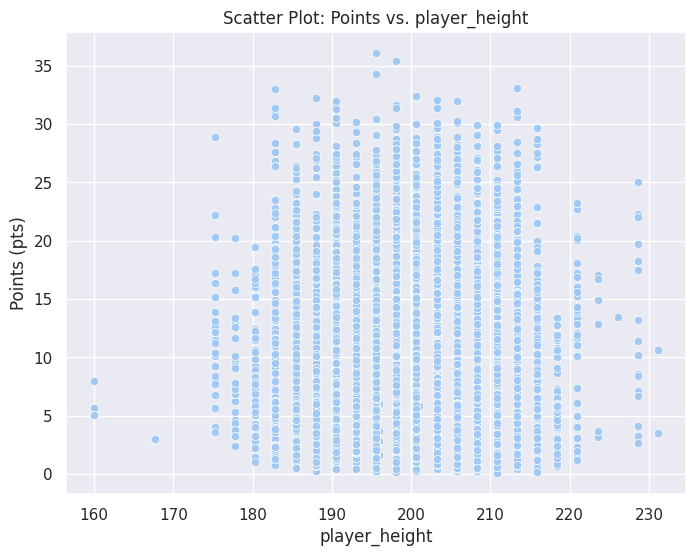

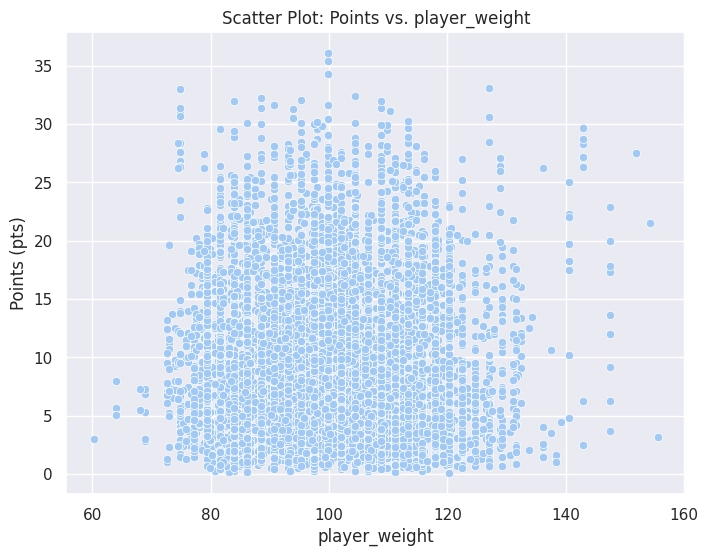

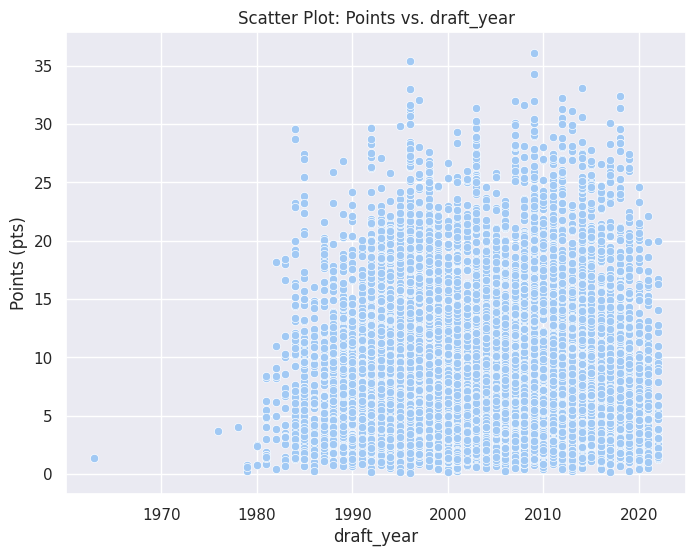

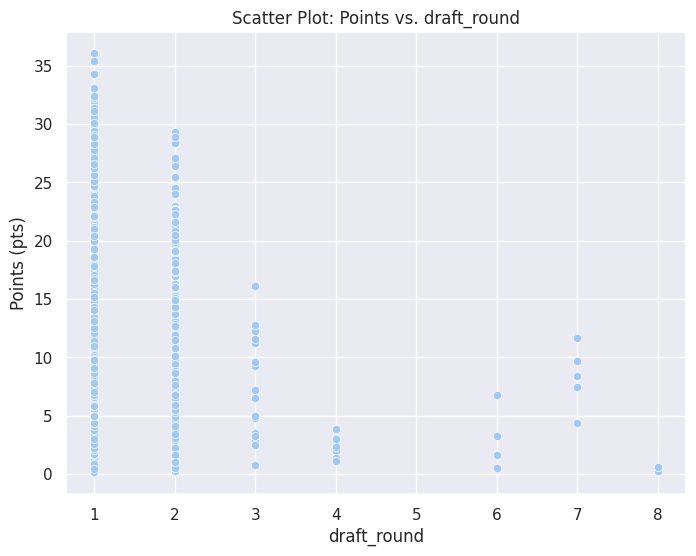

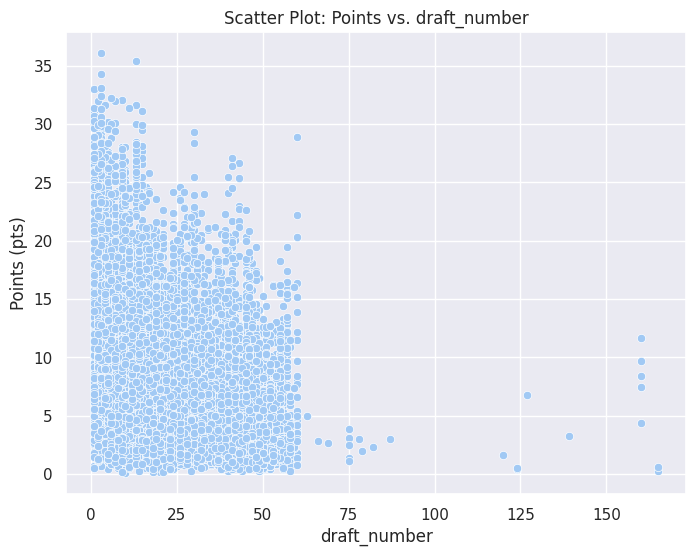

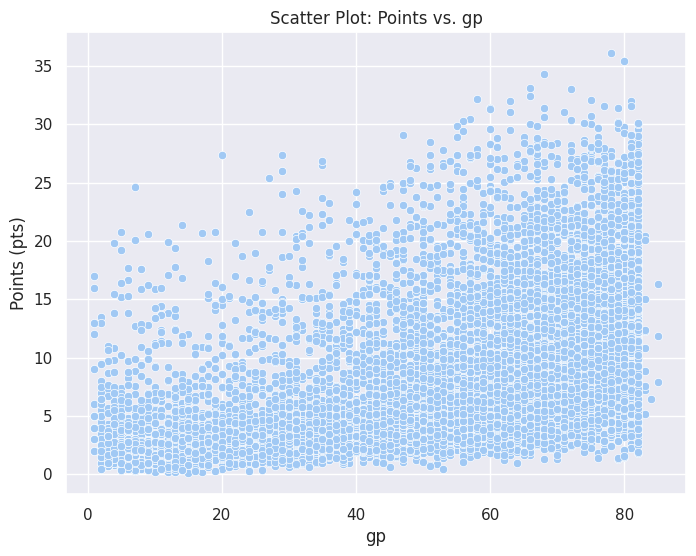

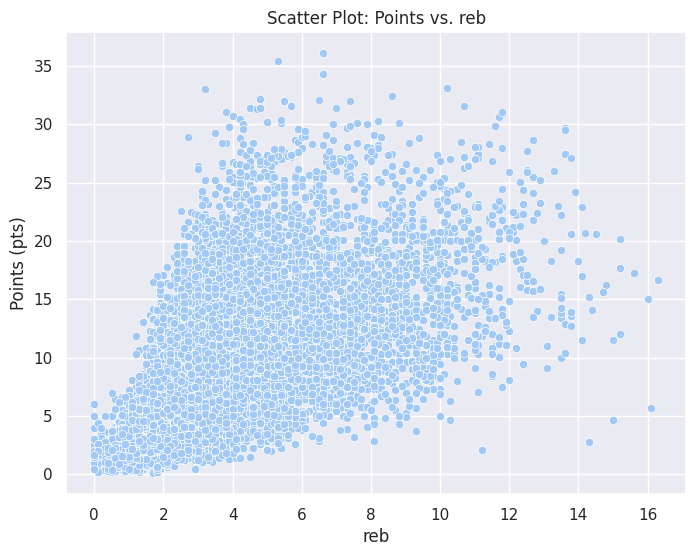

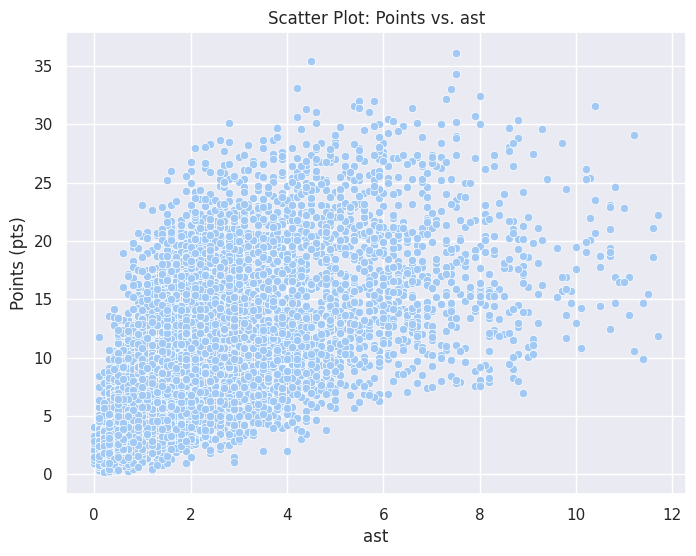

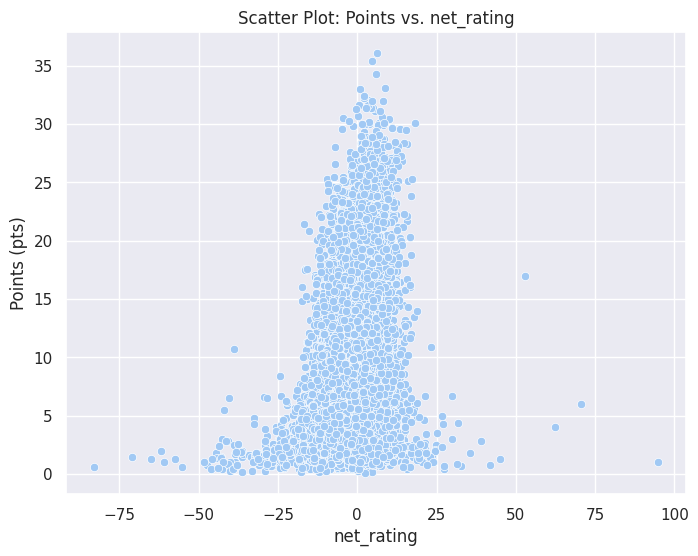

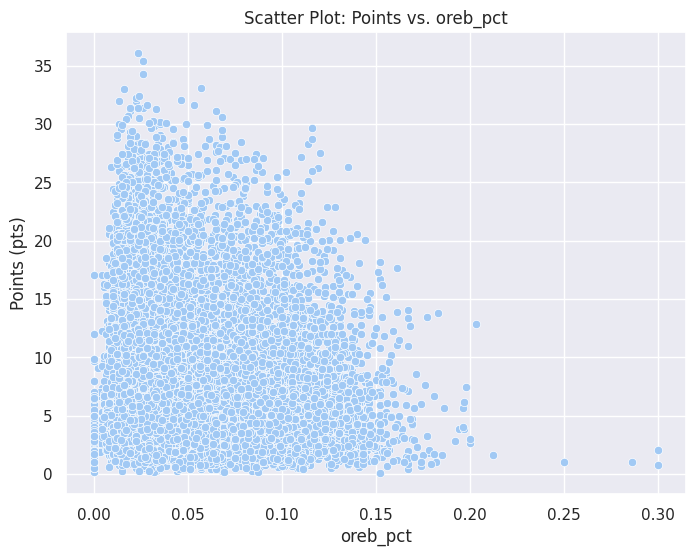

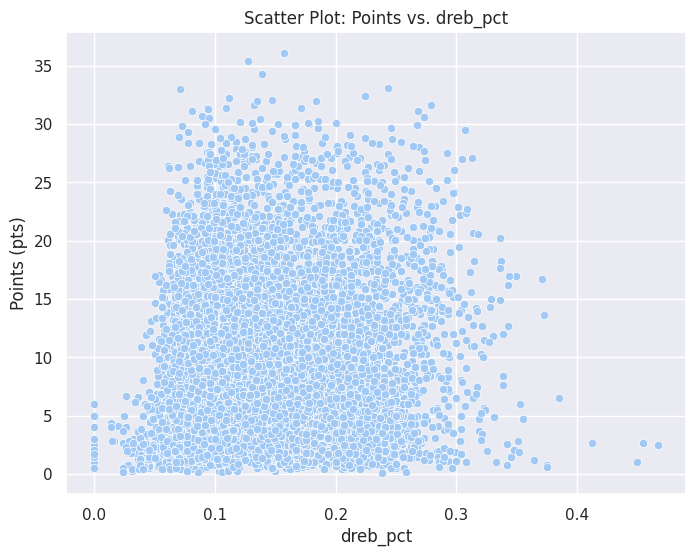

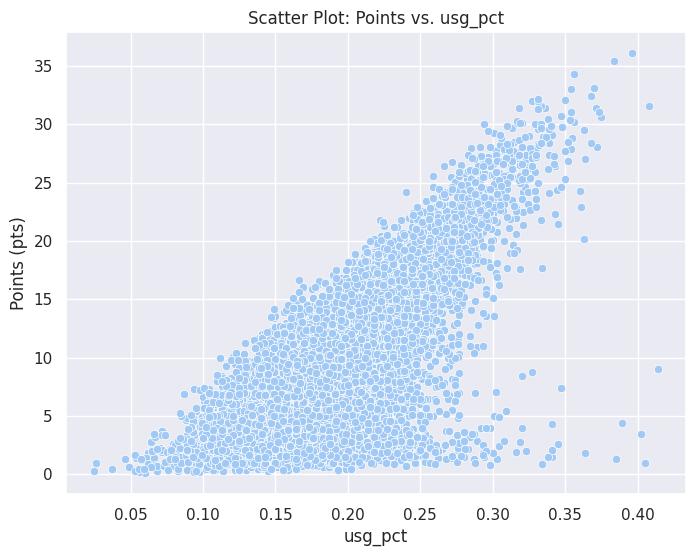

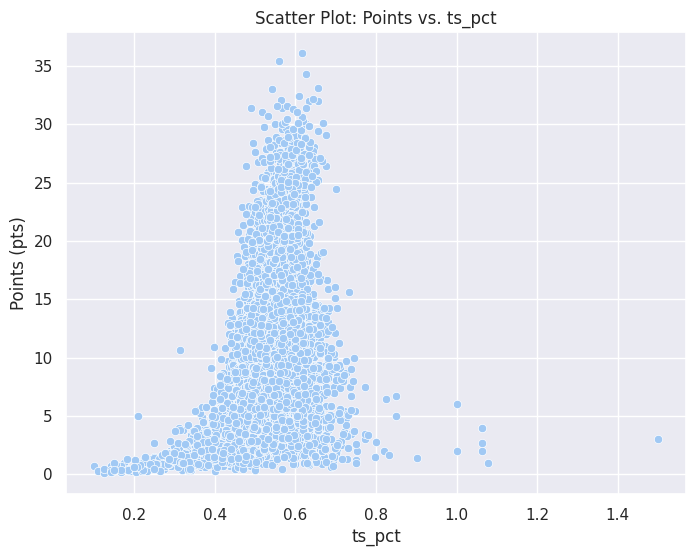

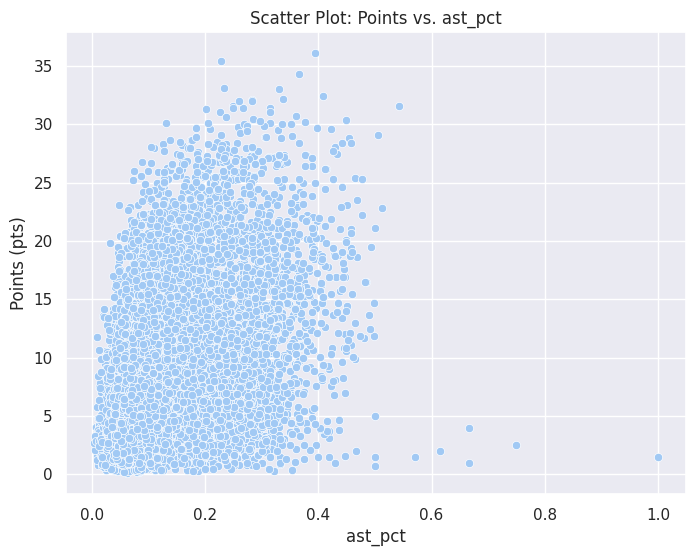

In [ ]:
other_numerical_cols = [col for col in numerical_cols if col != 'pts']

for col in other_numerical_cols:
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed
    sns.scatterplot(x=col, y='pts', data=data)
    plt.title(f'Scatter Plot: Points vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Points (pts)')
    plt.show()

In [ ]:
data.describe()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000,10178.000000
mean,27.056396,201.141845,100.976272,2003.997642,1.297210,21.634997,55.724700,9.202004,3.926901,2.008174,-1.386834,0.054580,0.143987,0.189360,0.523606,0.135373
std,4.476502,8.899086,12.331902,8.970544,0.501539,15.972866,22.450248,6.149121,2.517025,1.870998,7.911956,0.038878,0.057105,0.050467,0.071730,0.090516
min,18.000000,160.020000,60.327736,1963.000000,1.000000,1.000000,1.000000,0.100000,0.000000,0.000000,-82.900000,0.000000,0.000000,0.025000,0.101000,0.004000
25%,24.000000,195.580000,92.079176,1997.000000,1.000000,9.000000,41.000000,4.400000,2.100000,0.700000,-5.700000,0.022000,0.099000,0.154000,0.490000,0.070000
50%,26.000000,203.200000,100.243832,2004.000000,1.000000,19.000000,62.000000,7.800000,3.400000,1.400000,-0.900000,0.042000,0.135000,0.185000,0.529000,0.107000
75%,30.000000,208.280000,109.315672,2011.000000,2.000000,32.000000,75.000000,12.700000,5.200000,2.700000,3.300000,0.083000,0.182000,0.221000,0.564000,0.180000
max,44.000000,231.140000,155.582056,2022.000000,8.000000,165.000000,85.000000,36.100000,16.300000,11.700000,94.800000,0.300000,0.467000,0.414000,1.500000,1.000000


In [ ]:
data.isnull().sum()

,0
player_name,0
team_abbreviation,0
age,0
player_height,0
player_weight,0
college,1581
country,0
draft_year,0
draft_round,0
draft_number,0


In [ ]:
# Seperated data into numerical and categorical
obj_data=data.loc[:,['team_abbreviation','college','country','season']]  #Object data for encoding
players=data.loc[:,['player_name']]  #Player names to prepare for split
data.drop(columns=['player_name','team_abbreviation','college','country','season'],inplace=True) #Numerical data

X=data.drop(columns=['pts'])
y=data['pts']
X.head()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,22.0,193.04,94.800728,1996,2,42,64,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248
1,28.0,190.50,86.182480,1994,2,34,4,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043
2,26.0,203.20,103.418976,1993,1,12,41,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125
3,30.0,203.20,102.058200,1989,1,7,64,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125
4,23.0,213.36,119.748288,1995,1,22,52,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064


In [ ]:
#Foward Selection on Numerical Data
sfs = SequentialFeatureSelector(
    LinearRegression(),
    k_features=(1, X.shape[1]),
    forward=True,
    floating=True,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)
sfs.fit(X, y)
selected_features = list(sfs.k_feature_names_)
print(selected_features)
X=X[selected_features]

['age', 'draft_round', 'draft_number', 'gp', 'reb', 'ast', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']


In [ ]:
X.head()

,age,draft_round,draft_number,gp,reb,ast,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,22.0,2,42,64,1.5,2.4,0.042,0.071,0.169,0.487,0.248
1,28.0,2,34,4,1.3,0.3,0.030,0.111,0.174,0.497,0.043
2,26.0,1,12,41,6.4,1.9,0.106,0.185,0.175,0.512,0.125
3,30.0,1,7,64,2.8,1.7,0.027,0.111,0.206,0.527,0.125
4,23.0,1,22,52,1.7,0.3,0.102,0.169,0.195,0.500,0.064


In [ ]:
obj_data.head()

,team_abbreviation,college,country,season
0,HOU,Louisiana State,USA,1996-97
1,WAS,Northwestern Oklahoma,USA,1996-97
2,VAN,North Carolina,USA,1996-97
3,LAL,Florida State,USA,1996-97
4,DEN,UCLA,USA,1996-97


In [ ]:
print(len(obj_data['season'].value_counts()))
print(len(obj_data['team_abbreviation'].value_counts()))

27
36


In [ ]:
country_counts = obj_data['country'].value_counts()
filtered_counts = country_counts[country_counts > 50]
print(filtered_counts)

country
USA          8462
France        170
Canada        162
Spain          79
Turkey         74
Brazil         74
Slovenia       74
Croatia        68
Australia      61
Lithuania      60
Serbia         56
Name: count, dtype: int64


In [ ]:
print(len(country_counts))

64


In [ ]:
college_counts = obj_data['college'].value_counts()
filtered_counts1 = college_counts[college_counts > 100]
print(filtered_counts1)

college
Kentucky           397
Duke               365
North Carolina     329
UCLA               278
Arizona            266
Kansas             263
Connecticut        211
Michigan           175
Georgia Tech       156
Florida            155
Michigan State     154
Syracuse           142
Georgetown         138
Maryland           128
Texas              127
Stanford           119
Indiana            114
Memphis            114
Villanova          114
Wake Forest        114
Louisiana State    110
Washington         109
California         101
Name: count, dtype: int64


In [ ]:
print(len(college_counts))

246


In [ ]:
#For Country and College kept only the entries that appeared more than 50 or 100 times respectively. Replaced other entries with "other"
country_counts = obj_data['country'].value_counts()
countries_to_keep = country_counts[country_counts > 50].index
obj_data['country'] = obj_data['country'].apply(lambda x: x if x in countries_to_keep else 'Other')

college_counts = obj_data['college'].value_counts(dropna=False)
colleges_to_keep = college_counts[college_counts > 100].index
obj_data['college'] = obj_data['college'].apply(lambda x: x if x in colleges_to_keep else 'other')
obj_data['college'] = obj_data['college'].fillna('other').apply(lambda x: x if x in colleges_to_keep else 'other')

In [ ]:
obj_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   team_abbreviation  10178 non-null  object
 1   college            10178 non-null  object
 2   country            10178 non-null  object
 3   season             10178 non-null  object
dtypes: object(4)
memory usage: 318.2+ KB


In [ ]:
#Encoded Categorical Data and dropped the "other" columns we created
obj_data=pd.get_dummies(obj_data,prefix='fet')
obj_data=obj_data.replace({False:0,True:1})
obj_data.drop(columns=['fet_other', 'fet_Other'],inplace=True)

<ipython-input-63-f2ce03a4d05d>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  obj_data=obj_data.replace({False:0,True:1})


In [ ]:
obj_data.head()

,fet_ATL,fet_BKN,fet_BOS,fet_CHA,fet_CHH,fet_CHI,fet_CLE,fet_DAL,fet_DEN,fet_DET,...,fet_2013-14,fet_2014-15,fet_2015-16,fet_2016-17,fet_2017-18,fet_2018-19,fet_2019-20,fet_2020-21,fet_2021-22,fet_2022-23
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import statsmodels.api as sm
# Combined the 2 df together
X=pd.concat([X,obj_data],axis=1) # (10178,108)

x = X
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

# R2=0.921 , Adj. R2=0.920

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    pts   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     1107.
Date:                Wed, 04 Dec 2024   Prob (F-statistic):               0.00
Time:                        19:10:19   Log-Likelihood:                -20014.
No. Observations:               10178   AIC:                         4.024e+04
Df Residuals:                   10071   BIC:                         4.102e+04
Df Model:                         106                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -8.5824      0.214    -40.165      0.000      -9.001      -8.164
age                     0.0289      0.004      6.965      0.000       0.021       0.037
draft_round             0.4656      0.069      6.720      0.000       0.330       0.601
draft_number           -0.0159      0.002     -6.904      0.000      -0.020      -0.011
gp                      0.0111      0.001     10.945      0.000       0.009       0.013
reb                     1.1551      0.014     82.728      0.000       1.128       1.182
ast                     1.7092      0.023     73.130      0.000       1.663       1.755
oreb_pct              -23.8108      0.711    -33.489      0.000     -25.205     -22.417
dreb_pct              -22.1343      0.558    -39.658      0.000     -23.228     -21.040
usg_pct                59.2848      0.424    139.723      0.000      58.453      60.117
ts_pct                 10.6609      0.280     38.024      0.000      10.111      11.210
ast_pct               -26.1640      0.443    -59.097      0.000     -27.032     -25.296
fet_ATL                -0.1792      0.095     -1.896      0.058      -0.365       0.006
fet_BKN                -0.2929      0.141     -2.079      0.038      -0.569      -0.017
fet_BOS                -0.1076      0.094     -1.146      0.252      -0.292       0.076
fet_CHA                -0.4392      0.112     -3.928      0.000      -0.658      -0.220
fet_CHH                -0.4274      0.216     -1.980      0.048      -0.850      -0.004
fet_CHI                -0.3547      0.098     -3.619      0.000      -0.547      -0.163
fet_CLE                -0.2596      0.095     -2.726      0.006      -0.446      -0.073
fet_DAL                -0.3754      0.099     -3.808      0.000      -0.569      -0.182
fet_DEN                -0.1715      0.093     -1.839      0.066      -0.354       0.011
fet_DET                -0.3398      0.097     -3.493      0.000      -0.531      -0.149
fet_GSW                -0.1667      0.096     -1.733      0.083      -0.355       0.022
fet_HOU                -0.1988      0.097     -2.058      0.040      -0.388      -0.009
fet_IND                -0.3332      0.093     -3.566      0.000      -0.516      -0.150
fet_LAC                -0.3418      0.092     -3.718      0.000      -0.522      -0.162
fet_LAL                -0.0197      0.093     -0.211      0.833      -0.202       0.163
fet_MEM                -0.3291      0.102     -3.217      0.001      -0.530      -0.129
fet_MIA                -0.5476      0.100     -5.479      0.000      -0.744      -0.352
fet_MIL                -0.1040      0.093     -1.116      0.264      -0.287       0.079
fet_MIN                -0.2321      0.094     -2.477      0.013      -0.416      -0.048
fet_NJN                -0.0518      0.117     -0.443      0.657      -0.281       0.177
fet

In [ ]:
X.shape

(10178, 68)

In [ ]:
#Dropping features with p-val>0.05
p_values = model.pvalues

# list of features to remove
features_to_remove = []
for feature, p_value in p_values.items():
    if p_value > 0.05 and feature != 'const':
        features_to_remove.append(feature)

X = X.drop(columns=features_to_remove) # (10178,68)

In [ ]:
x = X
x = sm.add_constant(x)  # Use sm.add_constant directly
model = sm.OLS(y, x).fit()
model.summary()
# R2=0.921 , Adj. R2=0.920 (adj. R2 didnt change by dropping 40 fets)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    pts   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     1726.
Date:                Wed, 04 Dec 2024   Prob (F-statistic):               0.00
Time:                        19:12:35   Log-Likelihood:                -20030.
No. Observations:               10178   AIC:                         4.020e+04
Df Residuals:                   10109   BIC:                         4.070e+04
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -8.8388      0.220    -40.249      0.000      -9.269      -8.408
age                     0.0287      0.004      6.992      0.000       0.021       0.037
draft_round             0.4531      0.068      6.636      0.000       0.319       0.587
draft_number           -0.0160      0.002     -7.084      0.000      -0.020      -0.012
gp                      0.0111      0.001     11.162      0.000       0.009       0.013
reb                     1.1579      0.014     83.750      0.000       1.131       1.185
ast                     1.7068      0.023     73.631      0.000       1.661       1.752
oreb_pct              -23.9315      0.700    -34.175      0.000     -25.304     -22.559
dreb_pct              -22.1792      0.555    -39.944      0.000     -23.268     -21.091
usg_pct                59.2104      0.420    141.046      0.000      58.388      60.033
ts_pct                 10.7005      0.276     38.775      0.000      10.160      11.241
ast_pct               -26.1936      0.440    -59.492      0.000     -27.057     -25.331
fet_BKN                -0.1771      0.144     -1.227      0.220      -0.460       0.106
fet_CHA                -0.3229      0.115     -2.799      0.005      -0.549      -0.097
fet_CHH                -0.3213      0.222     -1.450      0.147      -0.756       0.113
fet_CHI                -0.2400      0.102     -2.362      0.018      -0.439      -0.041
fet_CLE                -0.1702      0.098     -1.734      0.083      -0.363       0.022
fet_DAL                -0.2592      0.102     -2.549      0.011      -0.458      -0.060
fet_DET                -0.2203      0.101     -2.191      0.029      -0.417      -0.023
fet_HOU                -0.0811      0.100     -0.813      0.416      -0.277       0.115
fet_IND                -0.2301      0.096     -2.388      0.017      -0.419      -0.041
fet_LAC                -0.2378      0.095     -2.499      0.012      -0.424      -0.051
fet_MEM                -0.2323      0.105     -2.206      0.027      -0.439      -0.026
fet_MIA                -0.4408      0.103     -4.281      0.000      -0.643      -0.239
fet_MIN                -0.1294      0.097     -1.333      0.183      -0.320       0.061
fet_NYK                -0.2216      0.098     -2.271      0.023      -0.413      -0.030
fet_ORL                -0.1340      0.097     -1.384      0.166      -0.324       0.056
fet_PHX                -0.4252      0.099     -4.311      0.000      -0.619      -0.232
fet_POR                -0.1431      0.095     -1.499      0.134      -0.330       0.044
fet_SAS                -0.4889      0.099     -4.962      0.000      -0.682      -0.296
fet_Connecticut         0.3960      0.123      3.216      0.001       0.155       0.637
fet_Duke                0.2987      0.095      3.154      0.002       0.113       0.484
fet

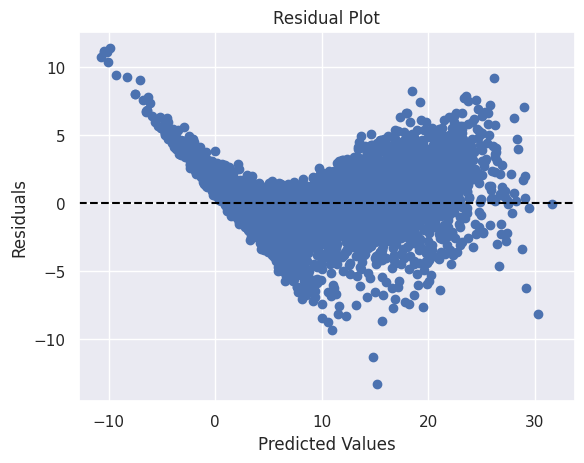

In [ ]:
#Residual Plot
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
res=y-y_pred

plt.scatter(y_pred,res,color='b')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
#Scaling data
from sklearn.model_selection import GroupShuffleSplit

scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

# Split the data making sure players that appear multiple times are grouped together
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=162)
train_idx, test_idx = next(gss.split(X, y, groups=players))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=162)

X.head()

,age,draft_round,draft_number,gp,reb,ast,oreb_pct,dreb_pct,usg_pct,ts_pct,...,fet_2010-11,fet_2011-12,fet_2012-13,fet_2013-14,fet_2014-15,fet_2015-16,fet_2016-17,fet_2017-18,fet_2018-19,fet_2021-22
0,-1.129597,1.401335,1.275037,0.368624,-0.964242,0.209431,-0.323586,-1.278189,-0.403450,-0.510356,...,-0.196126,-0.200408,-0.199611,-0.198812,-0.201467,-0.199079,-0.198812,-0.200143,-0.200408,-0.204093
1,0.210801,1.401335,0.774164,-2.304083,-1.043705,-0.913020,-0.632259,-0.577690,-0.304371,-0.370937,...,-0.196126,-0.200408,-0.199611,-0.198812,-0.201467,-0.199079,-0.198812,-0.200143,-0.200408,-0.204093
2,-0.235999,-0.592624,-0.603240,-0.655914,0.982597,-0.057819,1.322668,0.718234,-0.284555,-0.161809,...,-0.196126,-0.200408,-0.199611,-0.198812,-0.201467,-0.199079,-0.198812,-0.200143,-0.200408,-0.204093
3,0.657600,-0.592624,-0.916286,0.368624,-0.447734,-0.164719,-0.709427,-0.577690,0.329739,0.047320,...,-0.196126,-0.200408,-0.199611,-0.198812,-0.201467,-0.199079,-0.198812,-0.200143,-0.200408,-0.204093
4,-0.906198,-0.592624,0.022853,-0.165917,-0.884779,-0.913020,1.219777,0.438034,0.111764,-0.329111,...,-0.196126,-0.200408,-0.199611,-0.198812,-0.201467,-0.199079,-0.198812,-0.200143,-0.200408,-0.204093


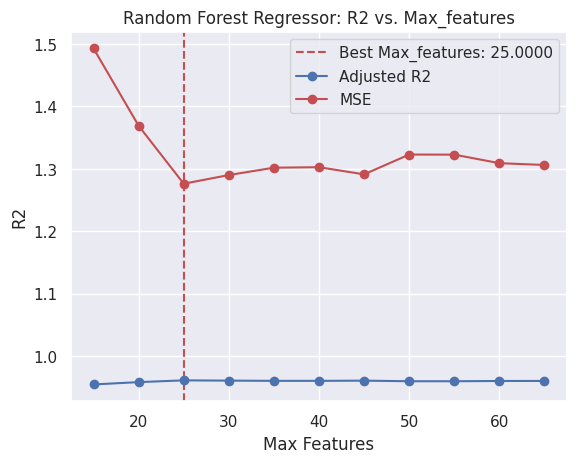

In [ ]:
## Optimizing RandomForestRegressor max_features
fet_vals=range(15,70,5)
adj_r2_scores=[]
mse_scores=[]

for i in fet_vals:
  RF_car = RFR(max_features=i,
            random_state=0).fit(X_train, y_train)
  y_pred = RF_car.predict(X_test)
  r2=r2_score(y_test, y_pred)
  mse_scores.append(mean_squared_error(y_test, y_pred))
  adj_r2_scores.append(1-(((1-r2)*(len(X_test)-1))/(len(X_test)-X_test.shape[1]-1)))

best_K = fet_vals[np.argmax(adj_r2_scores)]

plt.axvline(best_K, color='r', linestyle='--', label=f'Best Max_features: {best_K:.4f}')
plt.plot(fet_vals, adj_r2_scores,marker='o', label='Adjusted R2',color='b')
plt.plot(fet_vals, mse_scores,marker='o', label='MSE',color='r')
plt.xlabel('Max Features')
plt.ylabel('R2')
plt.title('Random Forest Regressor: R2 vs. Max_features')
plt.legend()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'n_estimators': [50,100,200,300],
    'max_depth': [None, 5,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2],
}


rf = RandomForestRegressor(max_features=25,random_state=162)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=15, scoring='r2',
                                   cv=3, n_jobs=-1, verbose=2, random_state=42)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

# Get the best model
best_rf_model = random_search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best score: 0.9558495300076096


In [ ]:
# 10 Most important features for Random Forest Regressor
feature_imp = pd.DataFrame(
    {'importance': best_rf_model.feature_importances_},
    index=X_train.columns
)

top_10_features = feature_imp.sort_values(by='importance', ascending=False).head(10)
print(top_10_features)

              importance
usg_pct         0.378008
ast             0.213395
reb             0.190431
ts_pct          0.064085
gp              0.040818
ast_pct         0.037278
draft_number    0.022768
dreb_pct        0.019266
oreb_pct        0.015473
age             0.004918


In [ ]:
from sklearn.model_selection import GridSearchCV

# Ridge regression
ridge = Ridge()
param_grid_ridge = {'alpha': np.logspace(-4, 4, 10)}
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, scoring='r2', cv=5)
grid_search_ridge.fit(X_train, y_train)
print("Best Ridge alpha:", grid_search_ridge.best_params_)

# Lasso regression
lasso = Lasso()
param_grid_lasso = {'alpha': np.logspace(-4, 4, 10)}
grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, scoring='r2', cv=10)
grid_search_lasso.fit(X_train, y_train)
print("Best Lasso alpha:", grid_search_lasso.best_params_)

Best Ridge alpha: {'alpha': 21.54434690031882}
Best Lasso alpha: {'alpha': 0.005994842503189409}


In [ ]:
#Optimizing ElasticNet
param_distributions = {
    'alpha': np.logspace(-5, 5, 100),
    'l1_ratio': np.arange(0, 1, 0.01)
}

elastic_net = ElasticNet()

random_search = RandomizedSearchCV(
    estimator=elastic_net,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

best_EN_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'l1_ratio': 0.73, 'alpha': 0.010722672220103232}
Best score: 0.9150585233760626


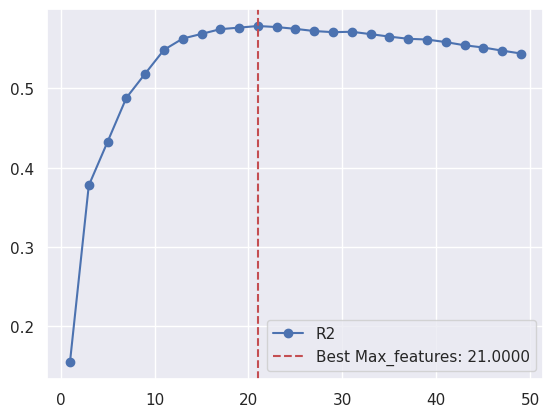

In [ ]:
#Optimizing KNN Regressor n_neighbors
from sklearn.neighbors import KNeighborsRegressor
fet_vals=range(1,50,2)
r2_scores=[]
for i in fet_vals:
  knn_model = KNeighborsRegressor(n_neighbors=i).fit(X_train, y_train)
  y_pred = knn_model.predict(X_test)
  r2_scores.append(r2_score(y_test, y_pred))

best_K = fet_vals[np.argmax(r2_scores)]

plt.plot(fet_vals, r2_scores,marker='o', label='R2',color='b')
plt.axvline(best_K, color='r', linestyle='--', label=f'Best Max_features: {best_K:.4f}')
plt.legend()

In [ ]:
!pip install xgboost
from xgboost import XGBRegressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=162)

param_dist = {
    'n_estimators': np.arange(50, 300, 25),
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0],
    'tree_method': ['auto', 'gpu_hist']
}


random_search = RandomizedSearchCV(xgb, param_dist, n_iter=50, cv=5, scoring='r2', n_jobs=-1)
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best R^2 score: {random_search.best_score_}")


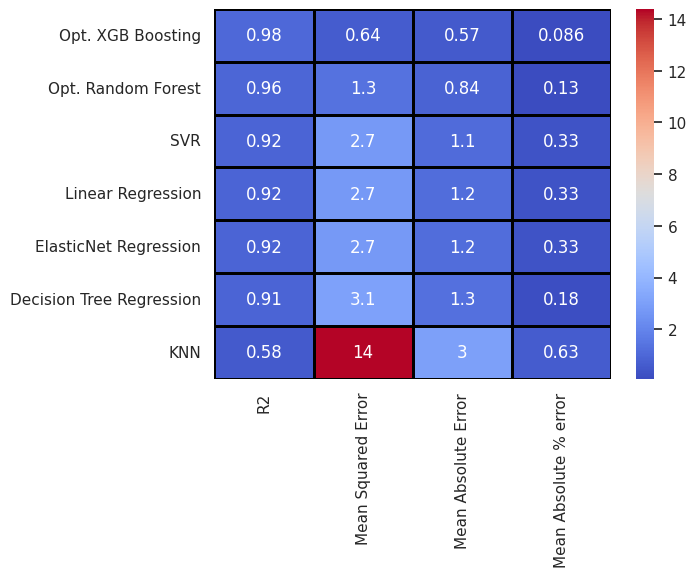

In [ ]:
# Fit all Optimized and other models and produced some scores (Removed Lasso and Ridge since they have the same socres as the base Linear model)
model_dic = {
    "Linear Regression": LinearRegression(),
    "ElasticNet Regression": best_EN_model,
    "Decision Tree Regression": DTR(),
    "Opt. Random Forest": best_rf_model,
    "SVR": SVR(kernel='linear'),
    "Opt. XGB Boosting": XGBRegressor(n_estimators=175,tree_method='auto',subsample=0.8,reg_lambda=1.0,reg_alpha=0.1,min_child_weight=10,max_depth=5,learning_rate=0.1,gamma=0,colsample_bytree=0.8),
    "KNN": KNeighborsRegressor(n_neighbors=21),
}

metric_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    metric_dic[i]={'R2':r2_score(y_test,y_pred),
                "Mean Squared Error"  :mean_squared_error(y_test,y_pred),
                "Mean Absolute Error"  :mean_absolute_error(y_test,y_pred),
                "Mean Absolute % error"  :mean_absolute_percentage_error(y_test, y_pred)}

metric_dic=pd.DataFrame(metric_dic)
metric_dic_transposed = metric_dic.T
metric_dic_sorted = metric_dic_transposed.sort_values(by=['R2'],ascending=False)

sns.heatmap(metric_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()

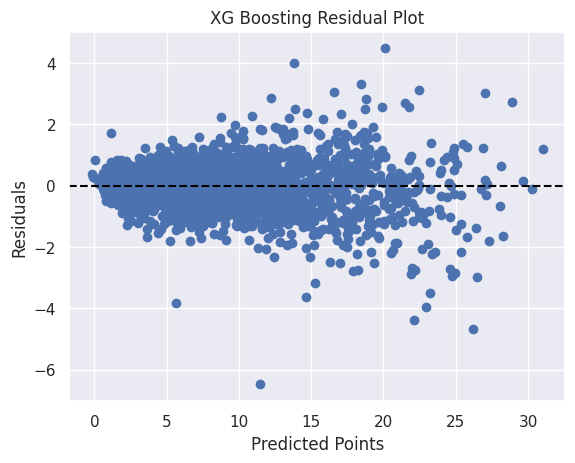

In [ ]:
#Residual Plot for best performing model
xgb= XGBRegressor(n_estimators=175,tree_method='auto',subsample=0.8,reg_lambda=1.0,reg_alpha=0.1,min_child_weight=10,max_depth=5,learning_rate=0.1,gamma=0,colsample_bytree=0.8)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
res=y_test-y_pred

plt.scatter(y_pred,res,color='b')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Points')
plt.ylabel('Residuals')
plt.title('XG Boosting Residual Plot')
plt.show()